In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Daten einlesen
# ===============================
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx", engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=7, nrows=9)
df.columns = ["x_B","T_bp","y_B"]

In [2]:
print(df.head(9))

        x_B  T_bp       y_B
0  0.837312    68  0.894123
1  0.705838    76  0.813100
2  0.571987    76  0.708136
3  0.447776    79  0.617727
4  0.328304    82  0.490213
5  0.216954    86  0.334986
6  0.096090    88  0.147150


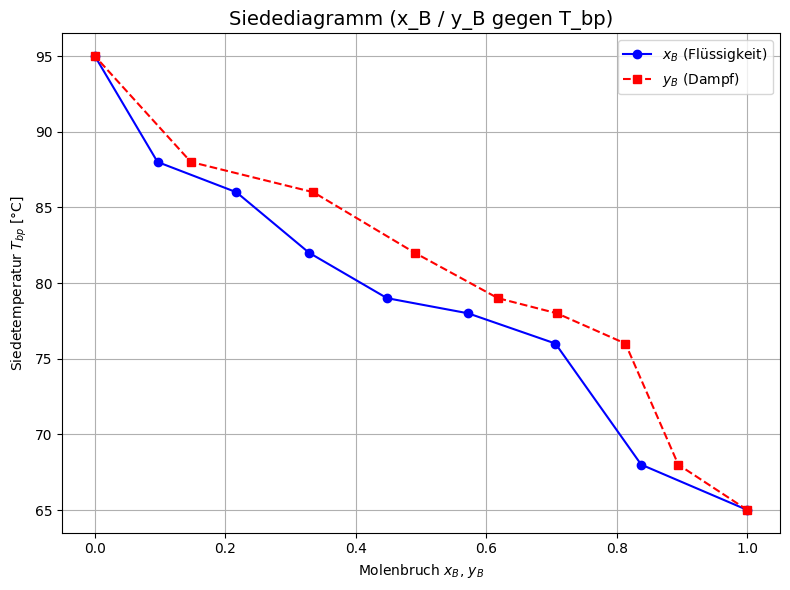

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten einlesen
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx",
                   engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=6, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Plot
plt.figure(figsize=(8, 6))

# Siedetemperatur gegen Molenbrüche in Flüssigkeit und Gas
plt.plot(df["x_B"], df["T_bp"], marker='o', linestyle='-', color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(df["y_B"], df["T_bp"], marker='s', linestyle='--', color='red', label=r'$y_B$ (Dampf)')

# Achsen und Layout
plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [°C]")
plt.title("Siedediagramm (x_B / y_B gegen T_bp)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

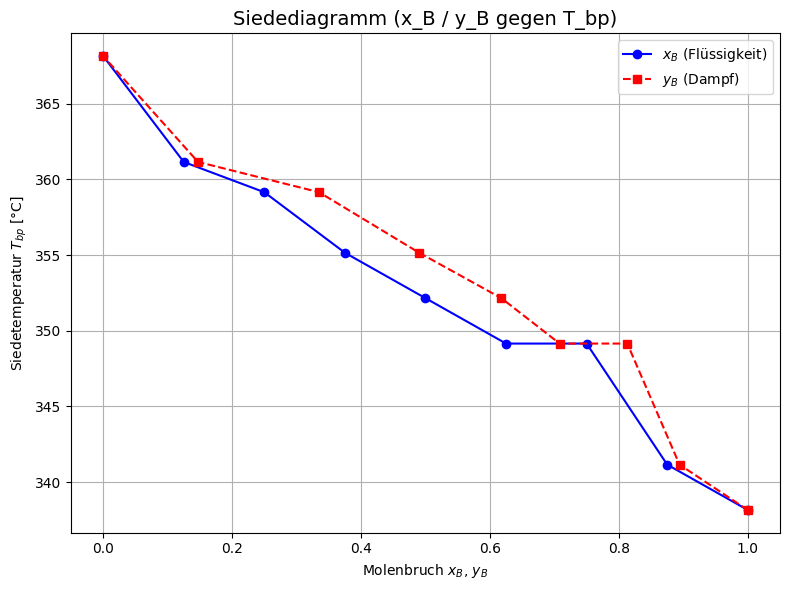

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten einlesen
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx",
                   engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=6, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Plot
plt.figure(figsize=(8, 6))

# Siedetemperatur gegen Molenbrüche in Flüssigkeit und Gas
plt.plot(df["x_B"], df["T_bp"], marker='o', linestyle='-', color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(df["y_B"], df["T_bp"], marker='s', linestyle='--', color='red', label=r'$y_B$ (Dampf)')

# Achsen und Layout
plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [°C]")
plt.title("Siedediagramm (x_B / y_B gegen T_bp)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Daten einlesen
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx",
                   engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=6, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Werte in Arrays
x_B = df["x_B"].values
y_B = df["y_B"].values
T_bp = df["T_bp"].values

# Feinere x-Achsenpunkte für Spline
x_fine = np.linspace(x_B.min(), x_B.max(), 300)
y_fine = np.linspace(y_B.min(), y_B.max(), 300)

# Spline-Kurven berechnen
spline_x = make_interp_spline(x_B, T_bp, k=3)
spline_y = make_interp_spline(y_B, T_bp, k=3)

T_x_spline = spline_x(x_fine)
T_y_spline = spline_y(y_fine)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x_fine, T_x_spline, color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(y_fine, T_y_spline, color='red', linestyle='--', label=r'$y_B$ (Dampf)')

# Messpunkte markieren
plt.plot(x_B, T_bp, 'o', color='blue')
plt.plot(y_B, T_bp, 's', color='red')

# Achsen und Layout
plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [°C]")
plt.title("Siedediagramm mit Spline-Interpolation", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

ValueError: Expect x to be a 1D strictly increasing sequence.

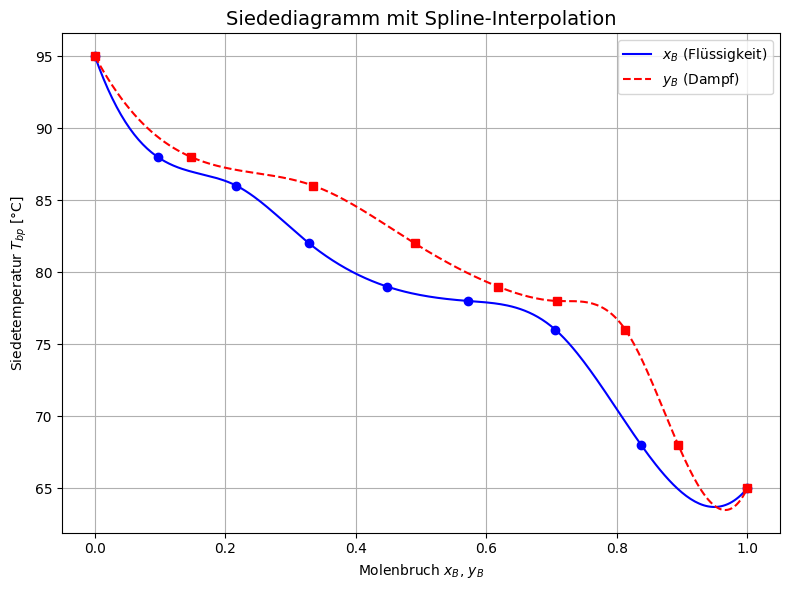

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Daten einlesen
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx",
                   engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=6, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Als Arrays
x_B = df["x_B"].values
y_B = df["y_B"].values
T_bp = df["T_bp"].values

# x_B sortieren (für Flüssigkeit)
sorted_x = np.argsort(x_B)
x_B_sorted = x_B[sorted_x]
T_x_sorted = T_bp[sorted_x]

# y_B sortieren (für Dampf)
sorted_y = np.argsort(y_B)
y_B_sorted = y_B[sorted_y]
T_y_sorted = T_bp[sorted_y]

# Feinere Punkte für glatte Kurven
x_fine = np.linspace(x_B_sorted.min(), x_B_sorted.max(), 300)
y_fine = np.linspace(y_B_sorted.min(), y_B_sorted.max(), 300)

# Spline-Funktionen
spline_x = make_interp_spline(x_B_sorted, T_x_sorted, k=3)
spline_y = make_interp_spline(y_B_sorted, T_y_sorted, k=3)

T_x_spline = spline_x(x_fine)
T_y_spline = spline_y(y_fine)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(x_fine, T_x_spline, color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(y_fine, T_y_spline, color='red', linestyle='--', label=r'$y_B$ (Dampf)')

# Originalpunkte
plt.plot(x_B, T_bp, 'o', color='blue')
plt.plot(y_B, T_bp, 's', color='red')

# Achsen & Layout
plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [°C]")
plt.title("Siedediagramm mit Spline-Interpolation", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

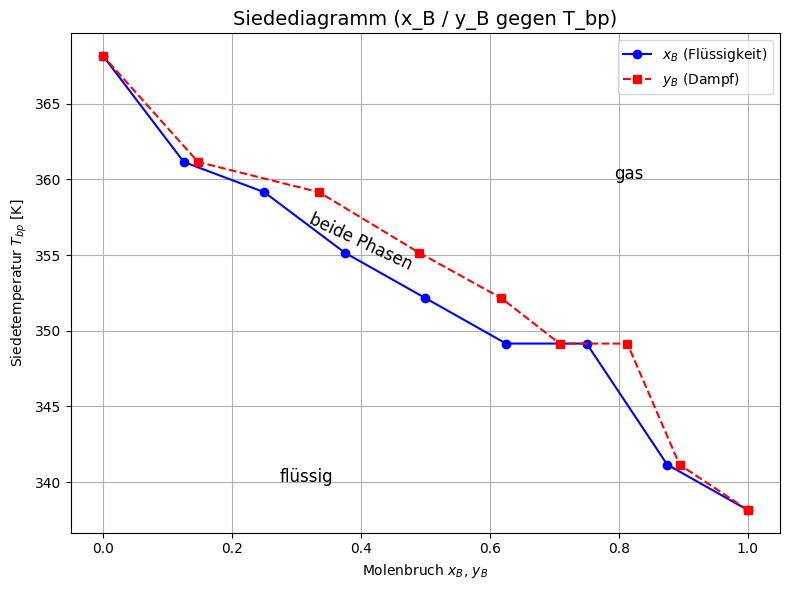

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Daten einlesen
df = pd.read_excel("Exp2-3_p(x)_T(x)_Template2025Kopie.xlsx",
                   engine="openpyxl",
                   usecols="AI,AL,AN", skiprows=6, nrows=9)
df.columns = ["x_B", "T_bp", "y_B"]

# Plot
plt.figure(figsize=(8, 6))

# Siedetemperatur gegen Molenbrüche in Flüssigkeit und Gas
plt.plot(df["x_B"], df["T_bp"], marker='o', linestyle='-', color='blue', label=r'$x_B$ (Flüssigkeit)')
plt.plot(df["y_B"], df["T_bp"], marker='s', linestyle='--', color='red', label=r'$y_B$ (Dampf)')

# Achsen und Layout
# Phasenbeschriftung
plt.text(0.315, 340, 'flüssig', fontsize=12, ha='center')
plt.text(0.815, 360, 'gas', fontsize=12, ha='center')
plt.text(0.4, 354, 'beide Phasen', fontsize=12, ha='center', rotation=335)

plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [K]")
plt.title("Siedediagramm (x_B / y_B gegen T_bp)", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
from scipy.interpolate import interp1d

# Interpolationsfunktion erzeugen
interp_xB = interp1d(df["x_B"], df["T_bp"], kind='cubic')
interp_yB = interp1d(df["y_B"], df["T_bp"], kind='cubic')

# Feineres x-Raster zum Glätten der Kurve
x_fine = np.linspace(df["x_B"].min(), df["x_B"].max(), 200)
y_fine = np.linspace(df["y_B"].min(), df["y_B"].max(), 200)

# Interpolierte T-Werte
T_interp_xB = interp_xB(x_fine)
T_interp_yB = interp_yB(y_fine)

# Phasenbeschriftung
plt.text(0.315, 185, 'flüssig', fontsize=12, ha='center')
plt.text(0.815, 340, 'gas', fontsize=12, ha='center')
plt.text(0.75, 340, 'beide Phasen', fontsize=12, ha='center', rotation=335)

# Plot
plt.figure(figsize=(8, 6))
plt.plot(df["x_B"], df["T_bp"], 'o', color='blue', label=r'Messpunkte $x_B$')
plt.plot(x_fine, T_interp_xB, '-', color='blue', label=r'Interpoliert $x_B$')

plt.plot(df["y_B"], df["T_bp"], 's', color='red', label=r'Messpunkte $y_B$')
plt.plot(y_fine, T_interp_yB, '--', color='red', label=r'Interpoliert $y_B$')

plt.xlabel("Molenbruch $x_B$, $y_B$")
plt.ylabel("Siedetemperatur $T_{bp}$ [°C]")
plt.title("Interpoliertes Siedediagramm", fontsize=14)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'df' is not defined